In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import scipy
from sandbox.jordan5 import setup_device
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sandbox.jordan8 import *

import json

In [2]:
from sandbox.plt_dict import matplotlib_update
matplotlib_update()

In [3]:
device = setup_device()

torch.manual_seed(0)
np.random.seed(0)

# Training from scratch

In [3]:
model = JordanNet(encode_dim=32)

training_dimensions = [4, 6, 9, 12, 15, 28]
for d in training_dimensions:
    model.add_dimension(d)

training_dataset = generate_training_datasets(matrices_per_class=2000,
                                              dimensions=training_dimensions)

model = train_jordan_net(
    model,
    training_dataset,
    num_epochs=50, 
    batch_size=64,
    lr=1e-3,
    device=device,
    train_transformer=True,
    patience=6,
)

Generating class with d=4, max_block_size=1...

Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Generating class with d=6, max_block_size=1...Done.
Generating class with d=6, max_block_size=2...Done.
Generating class with d=6, max_block_size=3...Done.
Generating class with d=6, max_block_size=4...Done.
Generating class with d=6, max_block_size=5...Done.
Generating class with d=6, max_block_size=6...Done.
Generating class with d=9, max_block_size=1...Done.
Generating class with d=9, max_block_size=2...Done.
Generating class with d=9, max_block_size=3...Done.
Generating class with d=9, max_block_size=4...Done.
Generating class with d=9, max_block_size=5...Done.
Generating class with d=9, max_block_size=6...Done.
Generating class with d=9, max_block_size=7...Done.
Generating class with d=9, max_block_size=8...Done.
Generating class with d=9, max_block_size=9...Done.
Generating class with d=12, max_block_size=1...Done.
Gener

c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\torch\nn\functional.py:3006: UserWarning: The operator 'aten::xlogy.OutTensor' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  reduced = torch.kl_div(input, target, reduction_enum, log_target=log_target)


Epoch [1/50] | Train Loss: 1.083635 | Val Loss: 1.741395 | LR: 9.99e-04
Epoch [2/50] | Train Loss: 0.814109 | Val Loss: 1.515418 | LR: 9.96e-04
Epoch [3/50] | Train Loss: 0.736629 | Val Loss: 1.260517 | LR: 9.91e-04
Epoch [4/50] | Train Loss: 0.676859 | Val Loss: 1.080705 | LR: 9.84e-04
Epoch [5/50] | Train Loss: 0.626662 | Val Loss: 0.905460 | LR: 9.76e-04
Epoch [6/50] | Train Loss: 0.588390 | Val Loss: 0.815690 | LR: 9.65e-04
Epoch [7/50] | Train Loss: 0.545017 | Val Loss: 0.690227 | LR: 9.52e-04
Epoch [8/50] | Train Loss: 0.508521 | Val Loss: 0.648249 | LR: 9.38e-04
Epoch [9/50] | Train Loss: 0.484085 | Val Loss: 0.564208 | LR: 9.22e-04
Epoch [10/50] | Train Loss: 0.458773 | Val Loss: 0.537019 | LR: 9.05e-04
Epoch [11/50] | Train Loss: 0.436404 | Val Loss: 0.467949 | LR: 8.85e-04
Epoch [12/50] | Train Loss: 0.415143 | Val Loss: 0.443476 | LR: 8.64e-04
Epoch [13/50] | Train Loss: 0.385690 | Val Loss: 0.415879 | LR: 8.42e-04
Epoch [14/50] | Train Loss: 0.356257 | Val Loss: 0.411896 | 

c:\Users\micha\Documents\Studia\Magisterka\sandbox\jordan8.py:445: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(filename))


# Tests

In [7]:
def run_test(model, d, matrices_per_class=1000, mode="random", eps=None, eps_range=None):
    model.eval()

    training_dataset = generate_training_datasets(
        matrices_per_class=matrices_per_class,
        dimensions=[d],
        mode=mode,
        eps=eps,
        eps_range=eps_range,
        device="cpu",
    )
    matrices, labels, features, masks, dists = training_dataset[d]
    loader = DataLoader(TensorDataset(features, labels, masks, dists), batch_size=64, shuffle=False)

    predicted_classes = []
    true_classes = labels.cpu().tolist()
    kl_avg = 0.0

    for batch_features, batch_labels, batch_masks, batch_dists in loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        batch_masks = batch_masks.to(device)
        batch_dists = batch_dists.to(device)

        logits = model(d, batch_features, masks=batch_masks)
        loss = kl_loss(logits, batch_dists)

        preds = torch.argmax(logits, dim=-1)
        predicted_classes += preds.cpu().tolist()
        kl_avg += loss.item() * batch_features.size(0)

    kl_avg /= len(loader.dataset)
    # print(f"Test KL Loss: {kl_avg:.6f}")

    return true_classes, predicted_classes, kl_avg

def test_jordan_net(model, d, matrices_per_class=1000, filename=None):
    if filename is None:
        filename = f"sandbox/jordan8_results/results_{d}.json"

    results = []

    for eps in [0.0, 1e-6, 1e-4, 1e-2, 1e-1, 1]:
        print(f"Testing with eps={eps}")
        true_classes, predicted_classes, kl_avg = run_test(model, d, matrices_per_class=matrices_per_class, mode="random", eps=eps)
        results.append({
            "eps": eps,
            "true_classes": true_classes,
            "predicted_classes": predicted_classes,
            "kl_avg": kl_avg,
        })
    
    print(f"Testing mode 'ortho'")
    true_classes, predicted_classes, kl_avg = run_test(model, d, matrices_per_class=matrices_per_class, mode="ortho", eps=0.0)
    results.append({
        "eps": "ortho",
        "true_classes": true_classes,
        "predicted_classes": predicted_classes,
        "kl_avg": kl_avg,
    })
    with open(filename, "w") as f:
        json.dump(results, f, indent=4)
    
def visualize_test_results(d, filename):
    with open(filename, "r") as f:
        results = json.load(f) 
    
    for result in results:
        eps = result["eps"]
        true_classes = result["true_classes"]
        predicted_classes = result["predicted_classes"]
        
        cm = confusion_matrix(true_classes, predicted_classes, labels=list(range(d)))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1, d+1)))
        disp.plot(cmap=plt.cm.Blues)
        title = f"{'eps='+str(eps) if eps != 'ortho' else 'ortho'}. KL Loss: {result['kl_avg']:.6f}, accuracy: {np.trace(cm) / np.sum(cm):.4f}"
        plt.title(title)
        plt.show()
    
def print_test_results(d, filename):
    with open(filename, "r") as f:
        results = json.load(f)

    print(f"\nTest results for dimension {d}:") 
    
    for result in results:
        eps = result["eps"]
        true_classes = result["true_classes"]
        predicted_classes = result["predicted_classes"]
        
        cm = confusion_matrix(true_classes, predicted_classes, labels=list(range(d)))
        title = f"\t{'eps='+f'{eps:<10}' if eps != 'ortho' else 'ortho     '}\t KL Loss: {result['kl_avg']:.6f},\t accuracy: {np.trace(cm) / np.sum(cm):.4f}"
        print(title)

In [4]:
model = JordanNet(encode_dim=32)
training_dimensions = [4, 6, 9, 12, 15, 28]
for d in training_dimensions:
    model.add_dimension(d)
model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth"))
model.to(device)
for d in training_dimensions:
    test_jordan_net(model, d, matrices_per_class=1000)

Testing with eps=0.0
Generating class with d=4, max_block_size=1...

C:\Users\micha\AppData\Local\Temp\ipykernel_9920\2942514706.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth"

Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.


c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\torch\nn\modules\transformer.py:720: UserWarning: The operator 'aten::_transformer_encoder_layer_fwd' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  return torch._transformer_encoder_layer_fwd(


Testing with eps=1e-06
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=0.0001
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=0.01
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=0.1
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=1
Generating class with d=4, max_block_size=1...Done.
Generat

In [5]:
for d in training_dimensions:
    print_test_results(d, f"sandbox/jordan8_results/results_{d}.json")


Test results for dimension 4:
	eps=0.0       	 KL Loss: 0.061002,	 accuracy: 1.0000
	eps=1e-06     	 KL Loss: 0.039419,	 accuracy: 0.9998
	eps=0.0001    	 KL Loss: 0.594640,	 accuracy: 0.9968
	eps=0.01      	 KL Loss: 0.308381,	 accuracy: 0.6442
	eps=0.1       	 KL Loss: 1.319619,	 accuracy: 0.2530
	eps=1         	 KL Loss: 2.056544,	 accuracy: 0.2500
	ortho     	 KL Loss: 0.065939,	 accuracy: 1.0000

Test results for dimension 6:
	eps=0.0       	 KL Loss: 0.056051,	 accuracy: 0.9987
	eps=1e-06     	 KL Loss: 0.127102,	 accuracy: 0.9997
	eps=0.0001    	 KL Loss: 0.725785,	 accuracy: 0.9987
	eps=0.01      	 KL Loss: 0.287045,	 accuracy: 0.7790
	eps=0.1       	 KL Loss: 1.854256,	 accuracy: 0.1710
	eps=1         	 KL Loss: 2.439194,	 accuracy: 0.1640
	ortho     	 KL Loss: 0.053693,	 accuracy: 1.0000

Test results for dimension 9:
	eps=0.0       	 KL Loss: 0.112489,	 accuracy: 0.9993
	eps=1e-06     	 KL Loss: 0.193740,	 accuracy: 0.9998
	eps=0.0001    	 KL Loss: 0.416670,	 accuracy: 0.99

# Training + tests on additional dimensions

In [4]:
model = JordanNet(encode_dim=32).cpu()
pretrained_dimensions = [4, 6, 9, 12, 15, 28]
for d in pretrained_dimensions:
    model.add_dimension(d)

model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth", map_location="cpu"))
model.to(device)

new_dimensions = [35, 33, 25, 23, 19, 13, 7]

for d in new_dimensions:
    model.add_dimension(d)
    training_dataset = generate_training_datasets(matrices_per_class=1200,
                                                dimensions=[d])
    model = train_jordan_net(
        model,
        training_dataset,
        num_epochs=50,
        batch_size=64,
        lr=1e-3,
        device=device,
        train_transformer=False,
        history_filename=f"sandbox/history_jordan8_{d}.csv")

Generating class with d=35, max_block_size=1...

C:\Users\micha\AppData\Local\Temp\ipykernel_8920\3069904846.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth"

Done.
Generating class with d=35, max_block_size=2...Done.
Generating class with d=35, max_block_size=3...Done.
Generating class with d=35, max_block_size=4...Done.
Generating class with d=35, max_block_size=5...Done.
Generating class with d=35, max_block_size=6...Done.
Generating class with d=35, max_block_size=7...Done.
Generating class with d=35, max_block_size=8...Done.
Generating class with d=35, max_block_size=9...Done.
Generating class with d=35, max_block_size=10...Done.
Generating class with d=35, max_block_size=11...Done.
Generating class with d=35, max_block_size=12...Done.
Generating class with d=35, max_block_size=13...Done.
Generating class with d=35, max_block_size=14...Done.
Generating class with d=35, max_block_size=15...Done.
Generating class with d=35, max_block_size=16...Done.
Generating class with d=35, max_block_size=17...Done.
Generating class with d=35, max_block_size=18...Done.
Generating class with d=35, max_block_size=19...Done.
Generating class with d=35, ma

c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\torch\nn\functional.py:3006: UserWarning: The operator 'aten::xlogy.OutTensor' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  reduced = torch.kl_div(input, target, reduction_enum, log_target=log_target)


Epoch [1/50] | Train Loss: 1.882542 | Val Loss: 1.554265 | LR: 9.99e-04
Epoch [2/50] | Train Loss: 1.444525 | Val Loss: 1.368000 | LR: 9.96e-04
Epoch [3/50] | Train Loss: 1.291556 | Val Loss: 1.241912 | LR: 9.91e-04
Epoch [4/50] | Train Loss: 1.164198 | Val Loss: 1.119963 | LR: 9.84e-04
Epoch [5/50] | Train Loss: 1.053009 | Val Loss: 1.009017 | LR: 9.76e-04
Epoch [6/50] | Train Loss: 0.967323 | Val Loss: 0.931044 | LR: 9.65e-04
Epoch [7/50] | Train Loss: 0.887488 | Val Loss: 0.897932 | LR: 9.52e-04
Epoch [8/50] | Train Loss: 0.828475 | Val Loss: 0.843279 | LR: 9.38e-04
Epoch [9/50] | Train Loss: 0.764699 | Val Loss: 0.796896 | LR: 9.22e-04
Epoch [10/50] | Train Loss: 0.718890 | Val Loss: 0.756329 | LR: 9.05e-04
Epoch [11/50] | Train Loss: 0.682024 | Val Loss: 0.730567 | LR: 8.85e-04
Epoch [12/50] | Train Loss: 0.651769 | Val Loss: 0.800549 | LR: 8.64e-04
Epoch [13/50] | Train Loss: 0.626831 | Val Loss: 0.706269 | LR: 8.42e-04
Epoch [14/50] | Train Loss: 0.599921 | Val Loss: 0.669458 | 

c:\Users\micha\Documents\Studia\Magisterka\sandbox\jordan8.py:445: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(filename))


Generating class with d=33, max_block_size=1...Done.
Generating class with d=33, max_block_size=2...Done.
Generating class with d=33, max_block_size=3...Done.
Generating class with d=33, max_block_size=4...Done.
Generating class with d=33, max_block_size=5...Done.
Generating class with d=33, max_block_size=6...Done.
Generating class with d=33, max_block_size=7...Done.
Generating class with d=33, max_block_size=8...Done.
Generating class with d=33, max_block_size=9...Done.
Generating class with d=33, max_block_size=10...Done.
Generating class with d=33, max_block_size=11...Done.
Generating class with d=33, max_block_size=12...Done.
Generating class with d=33, max_block_size=13...Done.
Generating class with d=33, max_block_size=14...Done.
Generating class with d=33, max_block_size=15...Done.
Generating class with d=33, max_block_size=16...Done.
Generating class with d=33, max_block_size=17...Done.
Generating class with d=33, max_block_size=18...Done.
Generating class with d=33, max_block

In [5]:
model = JordanNet(encode_dim=32).cpu()
pretrained_dimensions = [4, 6, 9, 12, 15, 28]
for d in pretrained_dimensions:
    model.add_dimension(d)

new_dimensions = [35, 33, 25, 23, 19, 13, 7]

for d in new_dimensions:
    model.add_dimension(d)


model.load_state_dict(torch.load(f"sandbox/model_jordan8_modified.pth", map_location="cpu"))
model.to(device)

C:\Users\micha\AppData\Local\Temp\ipykernel_8920\3686752702.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8_mod

JordanNet(
  (encoders): ModuleDict(
    (4): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=16, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (6): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=36, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (9): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=81, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias

In [8]:
for d in new_dimensions:
    test_jordan_net(model, d, matrices_per_class=1000)

Testing with eps=0.0
Generating class with d=35, max_block_size=1...Done.
Generating class with d=35, max_block_size=2...Done.
Generating class with d=35, max_block_size=3...Done.
Generating class with d=35, max_block_size=4...Done.
Generating class with d=35, max_block_size=5...Done.
Generating class with d=35, max_block_size=6...Done.
Generating class with d=35, max_block_size=7...Done.
Generating class with d=35, max_block_size=8...Done.
Generating class with d=35, max_block_size=9...Done.
Generating class with d=35, max_block_size=10...Done.
Generating class with d=35, max_block_size=11...Done.
Generating class with d=35, max_block_size=12...Done.
Generating class with d=35, max_block_size=13...Done.
Generating class with d=35, max_block_size=14...Done.
Generating class with d=35, max_block_size=15...Done.
Generating class with d=35, max_block_size=16...Done.
Generating class with d=35, max_block_size=17...Done.
Generating class with d=35, max_block_size=18...Done.
Generating class

In [9]:
for d in new_dimensions:
    print_test_results(d, f"sandbox/jordan8_results/results_{d}.json")


Test results for dimension 35:
	eps=0.0       	 KL Loss: 0.996698,	 accuracy: 0.5806
	eps=1e-06     	 KL Loss: 0.242819,	 accuracy: 0.9899
	eps=0.0001    	 KL Loss: 0.193816,	 accuracy: 0.8529
	eps=0.01      	 KL Loss: 2.207176,	 accuracy: 0.2128
	eps=0.1       	 KL Loss: 27.068541,	 accuracy: 0.0172
	eps=1         	 KL Loss: 1.624639,	 accuracy: 0.0286
	ortho     	 KL Loss: 2.289350,	 accuracy: 0.3132

Test results for dimension 33:
	eps=0.0       	 KL Loss: 1.102413,	 accuracy: 0.5184
	eps=1e-06     	 KL Loss: 0.148598,	 accuracy: 0.9817
	eps=0.0001    	 KL Loss: 0.574612,	 accuracy: 0.8106
	eps=0.01      	 KL Loss: 2.420884,	 accuracy: 0.1877
	eps=0.1       	 KL Loss: 19.387646,	 accuracy: 0.0212
	eps=1         	 KL Loss: 1.580021,	 accuracy: 0.0303
	ortho     	 KL Loss: 3.070108,	 accuracy: 0.1596

Test results for dimension 25:
	eps=0.0       	 KL Loss: 1.072047,	 accuracy: 0.5453
	eps=1e-06     	 KL Loss: 0.106486,	 accuracy: 0.9850
	eps=0.0001    	 KL Loss: 0.673303,	 accuracy:

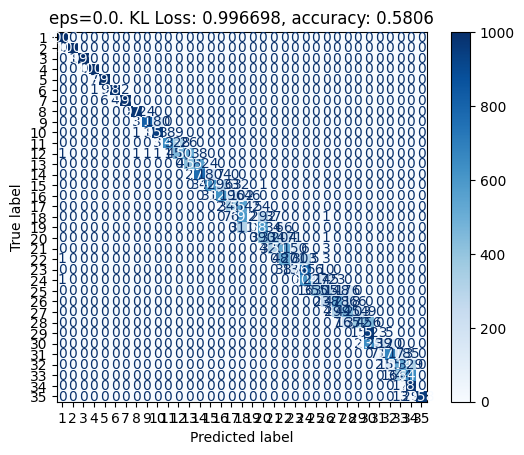

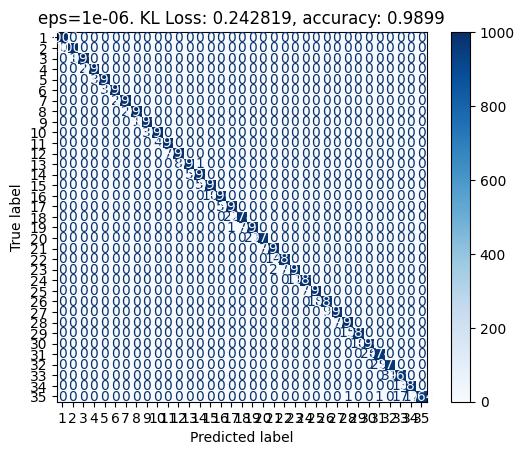

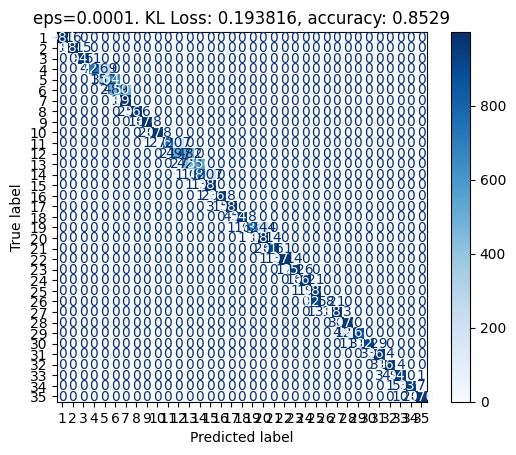

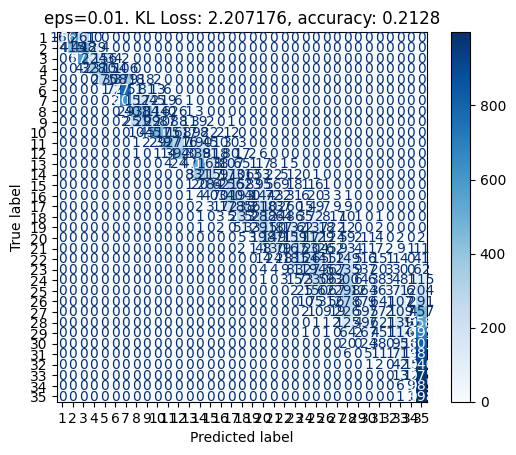

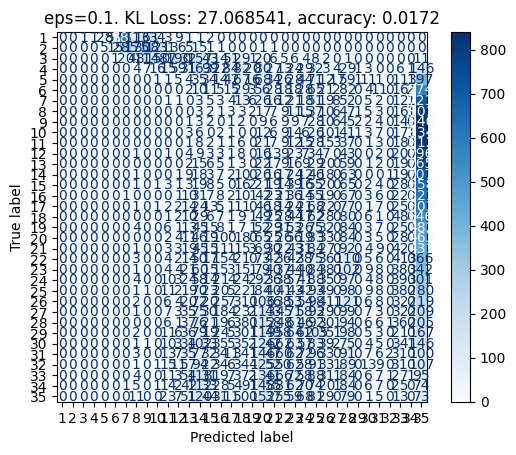

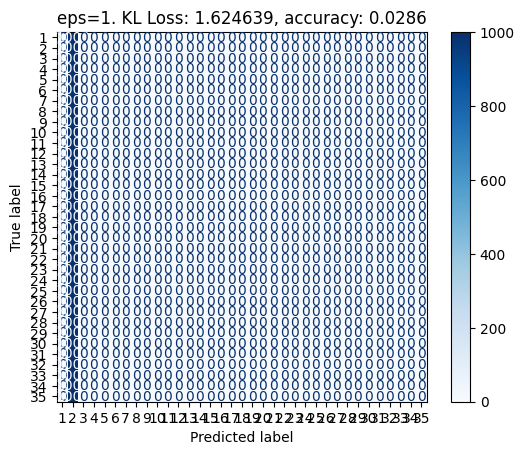

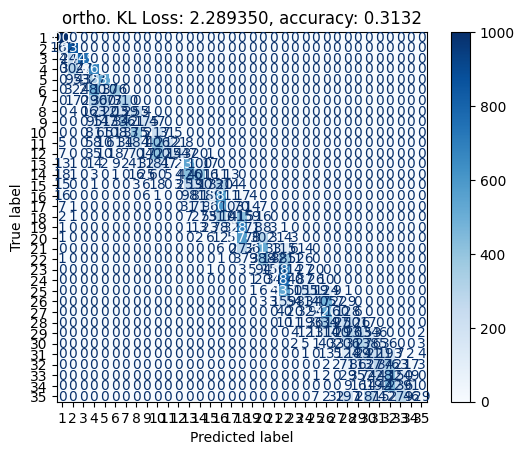

In [10]:
visualize_test_results(35, f"sandbox/jordan8_results/results_35.json")

# Test results comparison

In [ ]:
import os
import json
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_model_results(folder_path, epsilons, d_train, plot_filename=""):
    """
    Parses result JSONs and plots KL-loss and Accuracy across dimensions d.
    """
    # Data structure: { epsilon: { d_value: {'kl': [], 'acc': []} } }
    data = defaultdict(lambda: defaultdict(lambda: {'kl': None, 'acc': None}))
    
    # 1. Data Extraction
    for filename in os.listdir(folder_path):
        if filename.startswith("results_") and filename.endswith(".json"):
            try:
                d = int(filename.split('_')[1].split('.')[0])
            except ValueError:
                continue
                
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'r') as f:
                results = json.load(f)
            
            for entry in results:
                curr_eps = entry.get("eps")
                if curr_eps in epsilons:
                    preds = entry.get("predicted_classes", [])
                    trues = entry.get("true_classes", [])
                    acc = sum(1 for p, t in zip(preds, trues) if p == t) / len(trues) if trues else 0
                    
                    data[curr_eps][d]['kl'] = entry.get("kl_avg")
                    data[curr_eps][d]['acc'] = acc

    # 2. Preparation for Plotting
    sorted_eps = sorted(epsilons, key=lambda x: (str(type(x)), x))
    
    # --- FIGURE 1: KL Loss ---
    plt.figure(figsize=(6, 4))
    for eps in sorted_eps:
        sorted_ds = sorted(data[eps].keys())
        kl_vals = [data[eps][d]['kl'] for d in sorted_ds]
        label = f"$\epsilon$ = {eps}" if eps != 'ortho' else "Ortho"
        plt.plot(sorted_ds, kl_vals, marker='o', label=label)

    for d_val in d_train:
        plt.axvline(x=d_val, color='gray', linestyle='--', alpha=0.5)
        plt.text(d_val, plt.gca().get_ylim()[0], f' $d={d_val}$', 
                 rotation=90, verticalalignment='bottom', fontsize=8, color='gray')

    plt.xlabel("Dimension ($d$)")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, which='both', linestyle=':', alpha=0.5)
    plt.tight_layout()

    if plot_filename:
        plt.savefig(plot_filename + "_loss.pdf")

    # --- FIGURE 2: Accuracy ---
    plt.figure(figsize=(6, 4))
    for eps in sorted_eps:
        sorted_ds = sorted(data[eps].keys())
        acc_vals = [data[eps][d]['acc'] for d in sorted_ds]
        label = f"$\epsilon$ = {eps}" if eps != 'ortho' else "Ortho"
        plt.plot(sorted_ds, acc_vals, marker='s', label=label)

    for d_val in d_train:
        plt.axvline(x=d_val, color='gray', linestyle='--', alpha=0.5)
        plt.text(d_val, plt.gca().get_ylim()[0], f' $d={d_val}$', 
                 rotation=90, verticalalignment='bottom', fontsize=8, color='gray')

    plt.xlabel("Dimension ($d$)")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    
    if plot_filename:
        plt.savefig(plot_filename + "_accuracy.pdf")

    plt.show()

In [14]:
# def plot_model_results2(folder_path, epsilons, d_train):
#     """
#     Parses result JSONs and plots KL-loss and Accuracy across epsilons.
#     x-axis contains eps, each dimension d has a separate line.
#     Pretrained dimensions are marked with solid line, others with dashed line.
#     """
#     # Data structure: { d_value: { epsilon: {'kl': None, 'acc': None} } }
#     data = defaultdict(lambda: defaultdict(lambda: {'kl': None, 'acc': None}))
    
#     # 1. Data Extraction
#     for filename in os.listdir(folder_path):
#         if filename.startswith("results_") and filename.endswith(".json"):
#             # Extract d from filename (e.g., results_10.json -> 10)
#             try:
#                 d = int(filename.split('_')[1].split('.')[0])
#             except ValueError:
#                 continue
                
#             file_path = os.path.join(folder_path, filename)
#             with open(file_path, 'r') as f:
#                 results = json.load(f)
            
#             for entry in results:
#                 curr_eps = entry.get("eps")
                
#                 # Only process if this epsilon is in our target list
#                 if curr_eps in epsilons:
#                     # Calculate Accuracy
#                     preds = entry.get("predicted_classes", [])
#                     trues = entry.get("true_classes", [])
#                     acc = sum(1 for p, t in zip(preds, trues) if p == t) / len(trues) if trues else 0
                    
#                     # Store values
#                     data[d][curr_eps]['kl'] = entry.get("kl_avg")
#                     data[d][curr_eps]['acc'] = acc

#     # 2. Preparation for Plotting
#     # Sort epsilons for consistent ordering on x-axis
#     sorted_eps = sorted(epsilons, key=lambda x: (str(type(x)), x))
    
#     # For log-scale plotting, replace 0 with a very small value
#     plot_eps = [1e-8 if eps == 0 else eps for eps in sorted_eps]
#     eps_labels = ['0' if eps == 0 else str(eps) for eps in sorted_eps]
    
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
#     # Iterate over each dimension d
#     for d in sorted(data.keys()):
#         # Determine line style: solid for pretrained, dashed for others
#         linestyle = '-' if d in d_train else '--'
        
#         # Sort by epsilon to ensure lines connect correctly
#         kl_vals = [data[d][eps]['kl'] for eps in sorted_eps]
#         acc_vals = [data[d][eps]['acc'] for eps in sorted_eps]
        
#         label = f"d = {d}"
        
#         ax1.plot(plot_eps, kl_vals, marker='o', label=label, linestyle=linestyle)
#         ax2.plot(plot_eps, acc_vals, marker='s', label=label, linestyle=linestyle)

#     # Formatting
#     ax1.set_xlabel("Epsilon ($\epsilon$)")
#     ax1.set_ylabel("Loss")
#     ax1.set_xscale('log')
#     ax1.set_xticks(plot_eps)
#     ax1.set_xticklabels(eps_labels)
#     ax1.legend()
#     ax1.grid(True, linestyle=':', alpha=0.6)

#     ax2.set_xlabel("Epsilon ($\epsilon$)")
#     ax2.set_ylabel("Accuracy")
#     ax2.set_xscale('log')
#     ax2.set_xticks(plot_eps)
#     ax2.set_xticklabels(eps_labels)
#     ax2.legend()
#     ax2.grid(True, linestyle=':', alpha=0.6)

#     plt.tight_layout()
#     plt.show()

In [19]:
pretrained_dimensions = [4, 6, 9, 12, 15, 28]

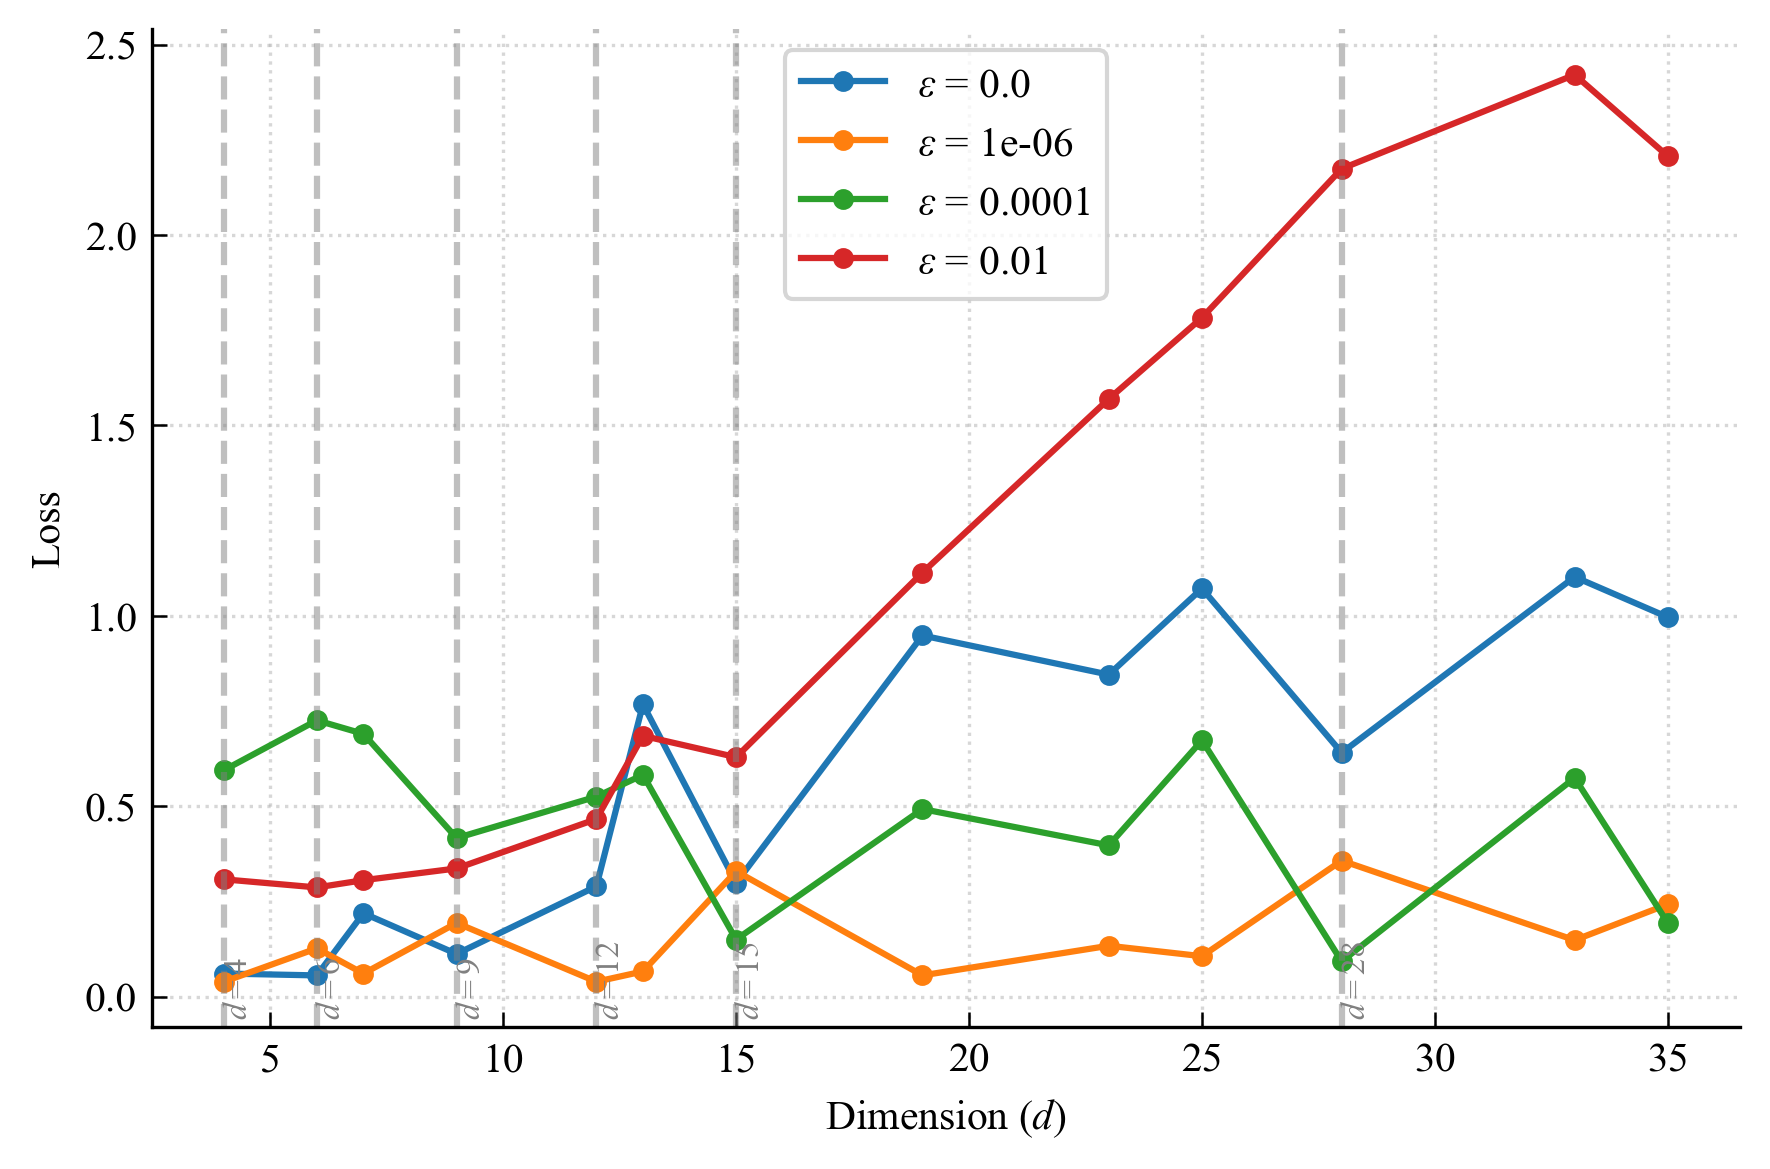

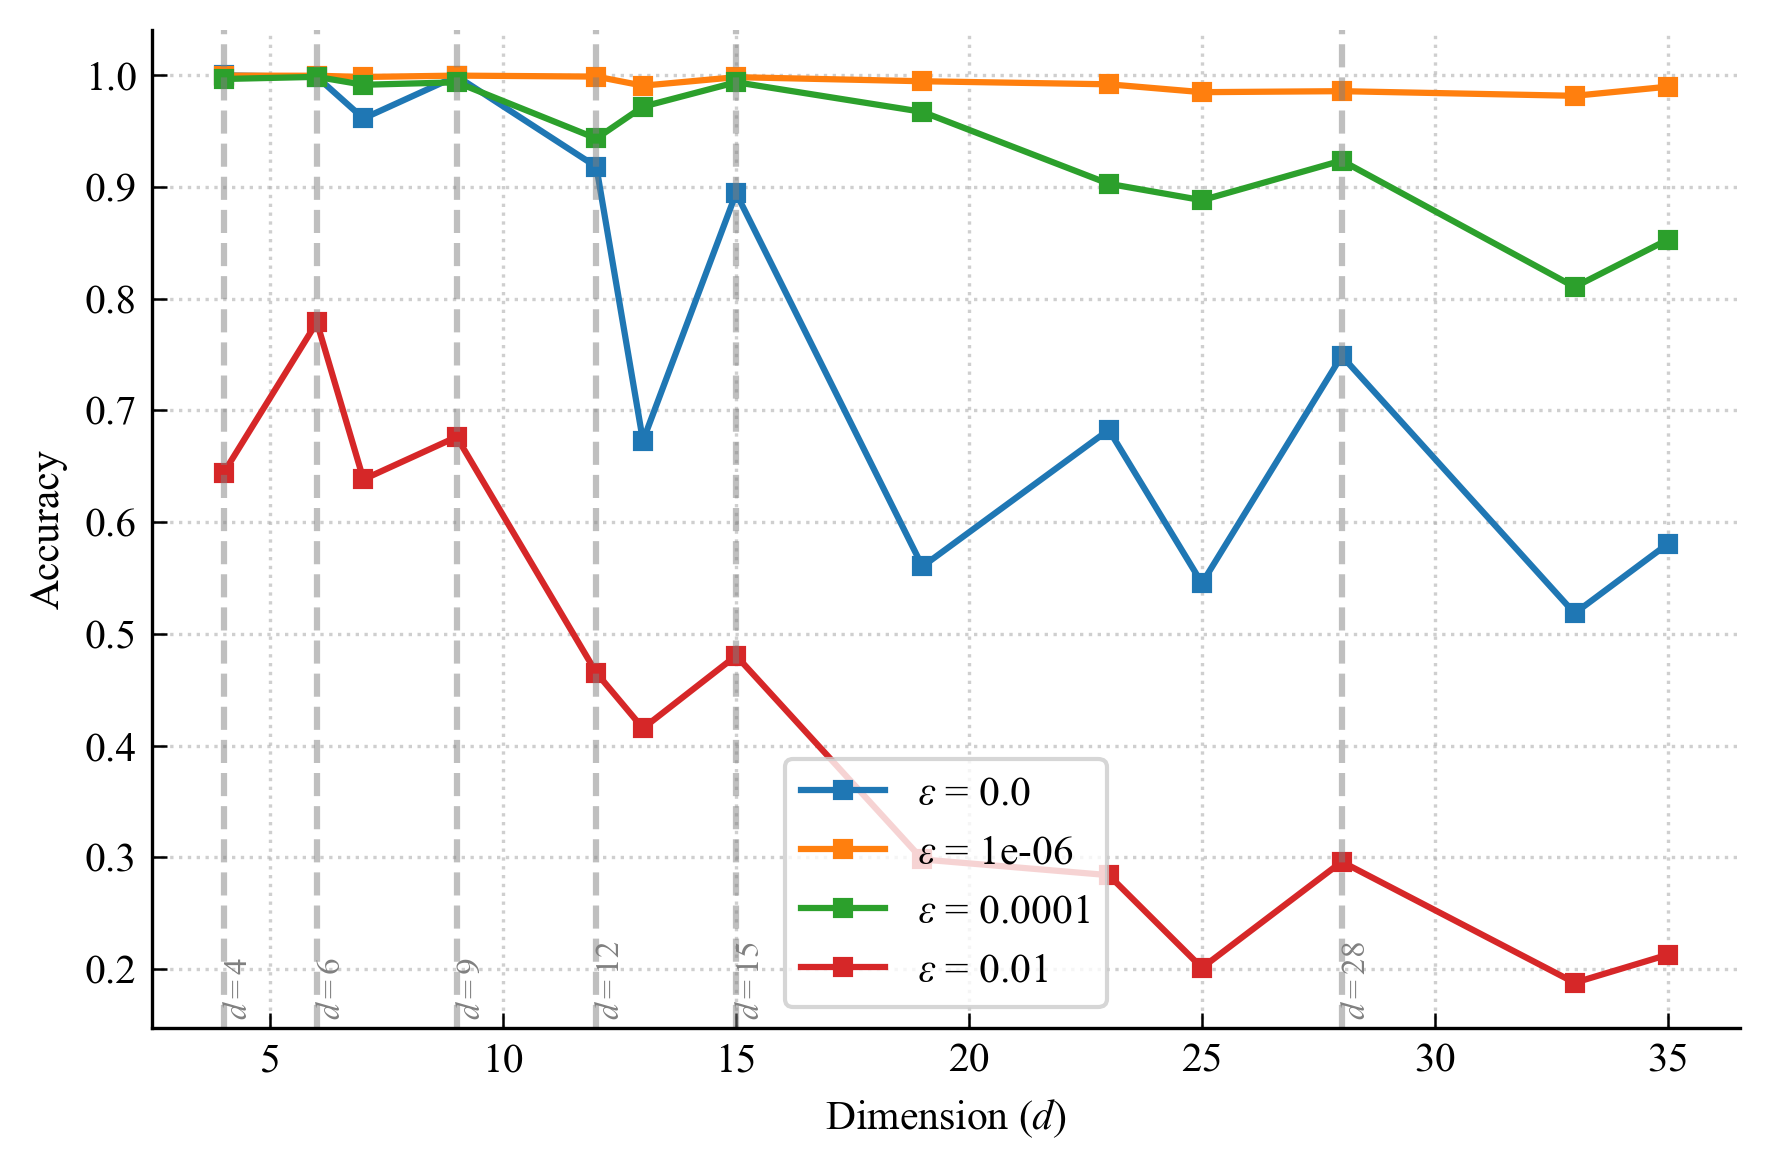

In [ ]:
plot_model_results('./sandbox/jordan8_results', [0.0, 1e-6, 1e-4, 1e-2], pretrained_dimensions, "latex/images/j8_a")

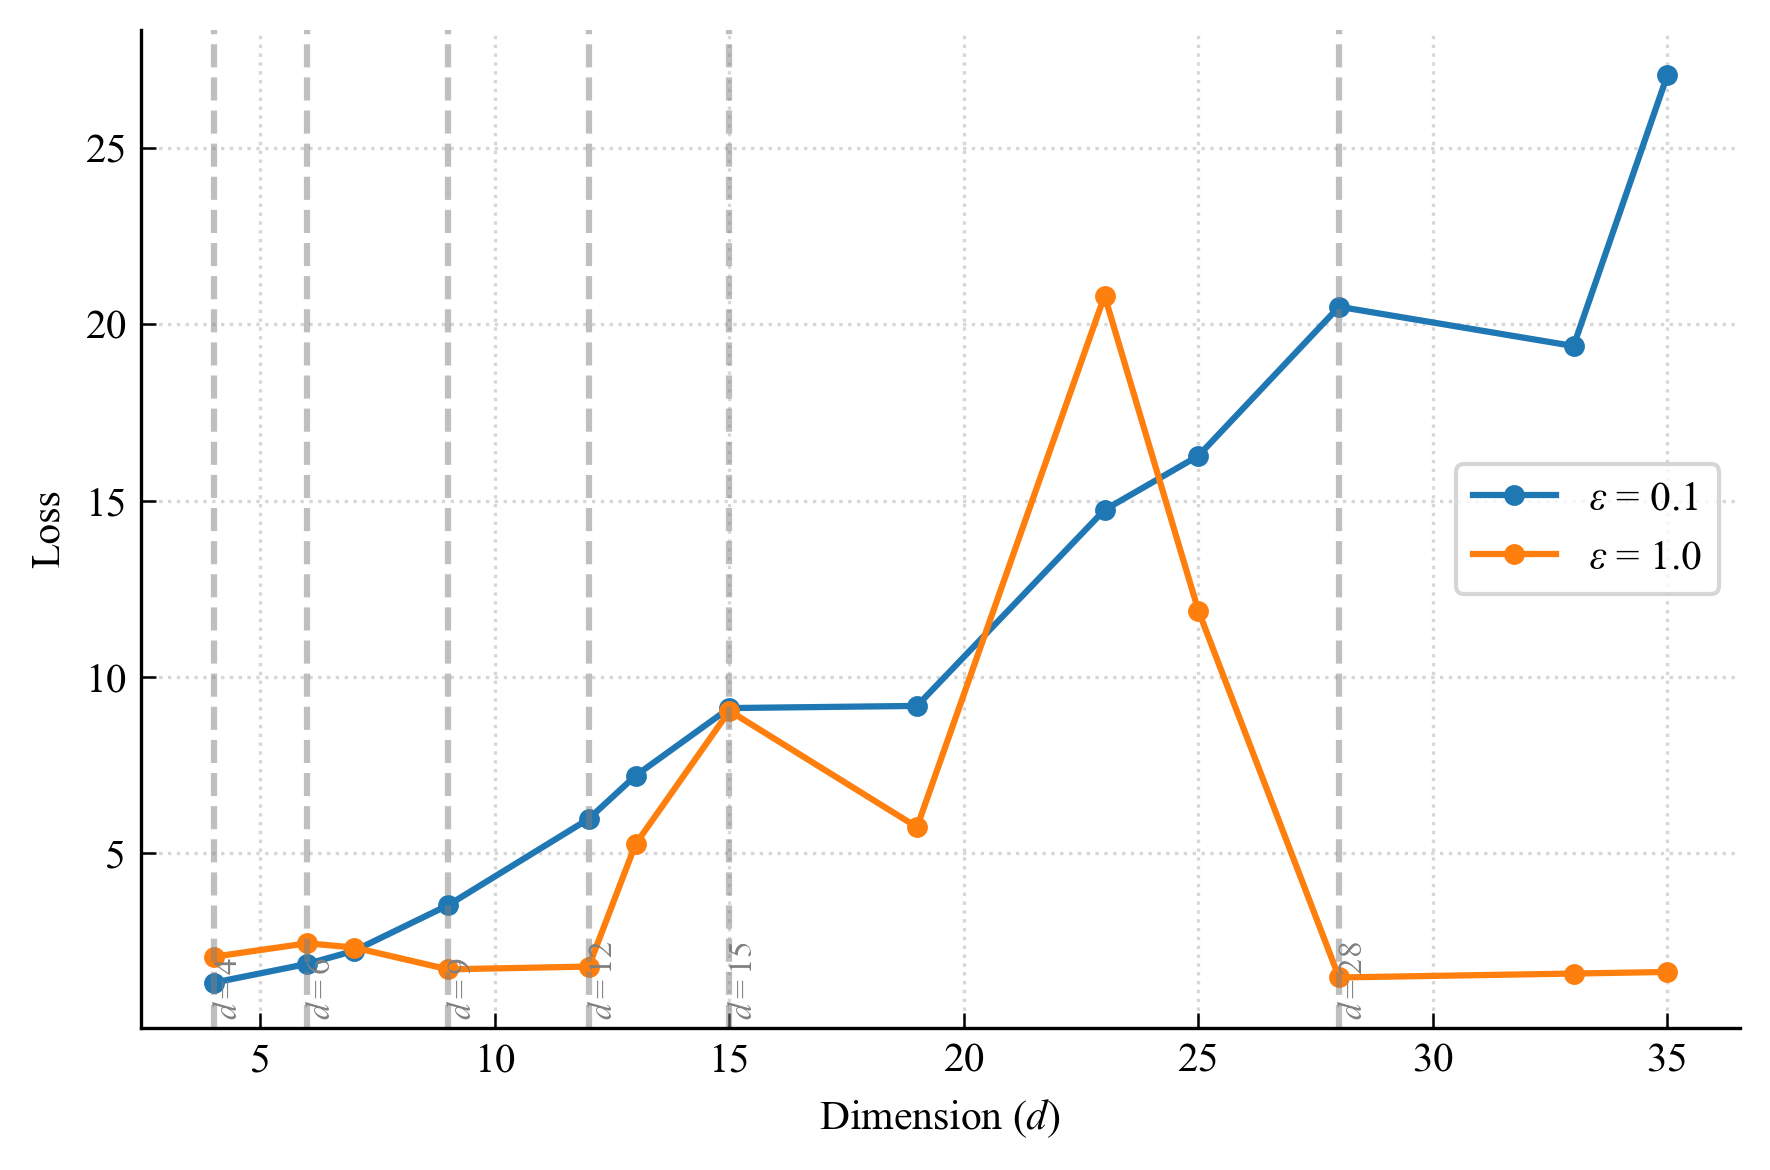

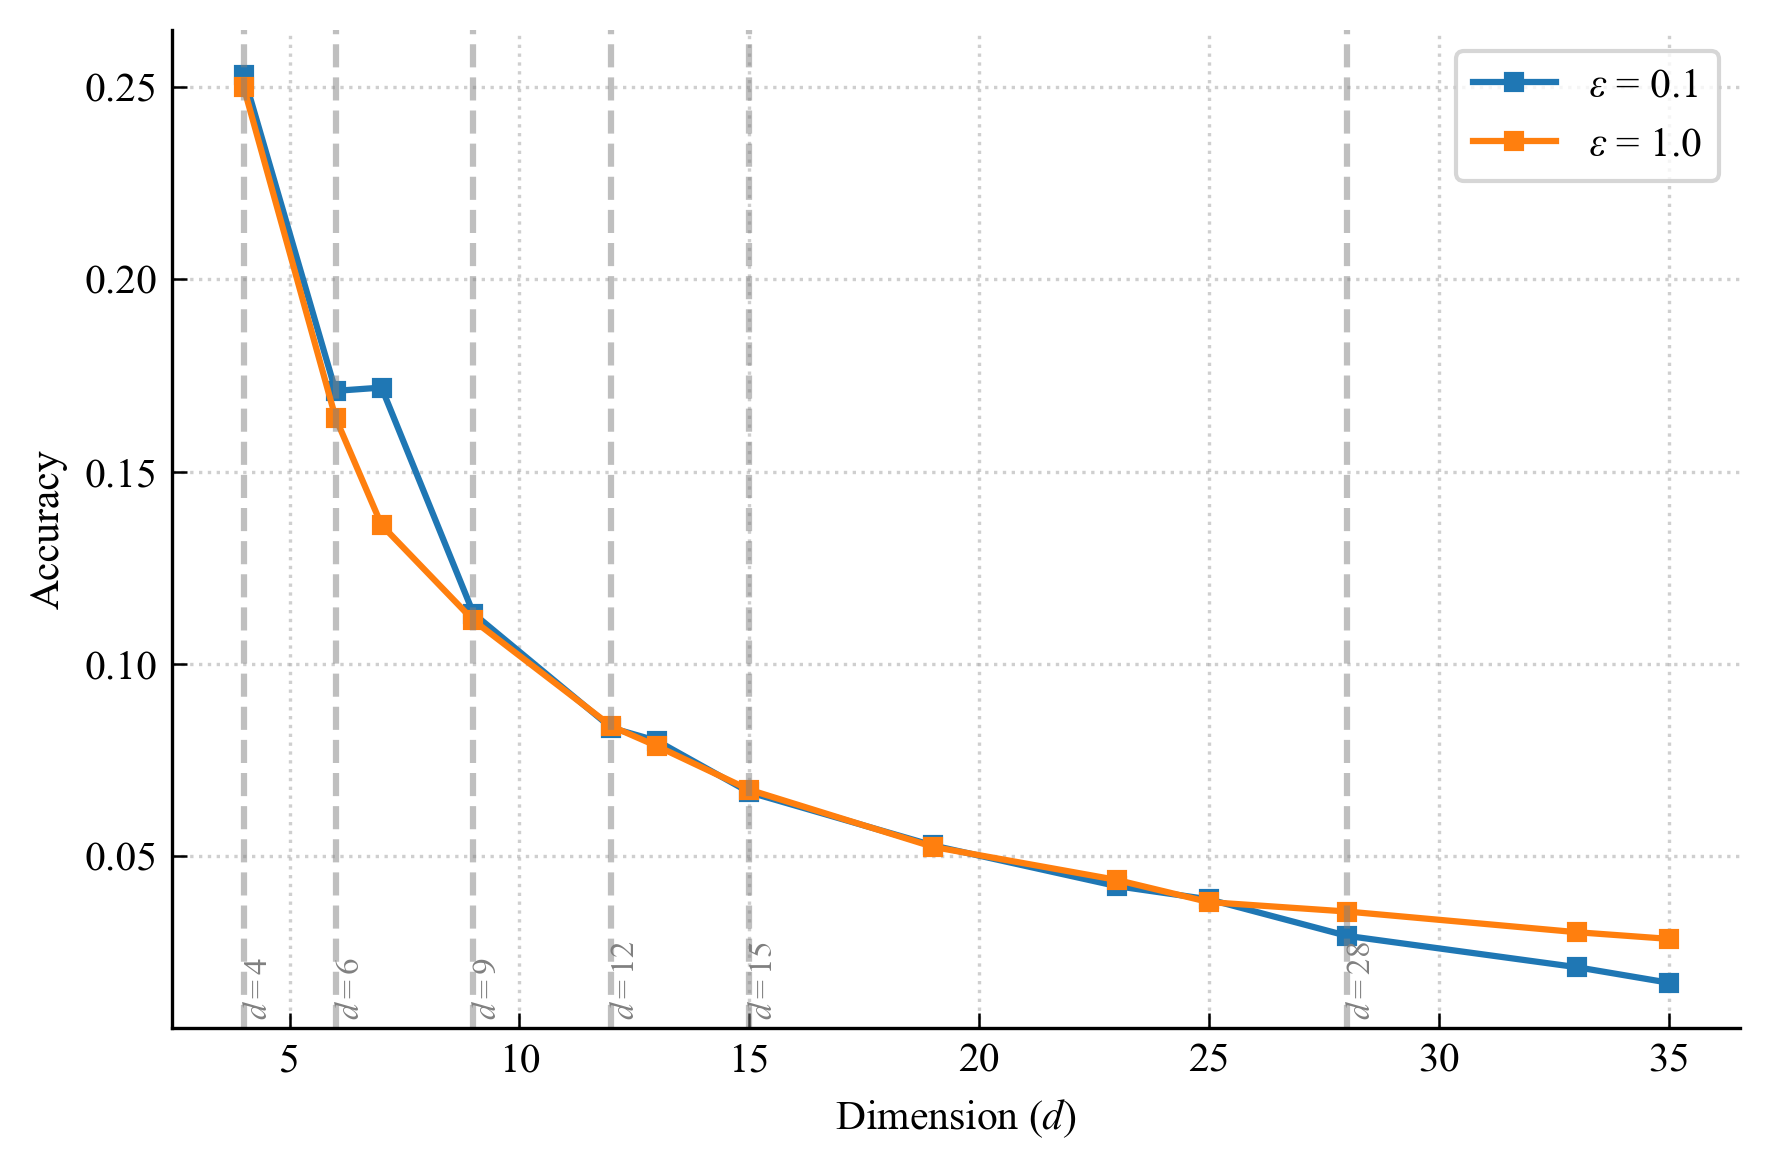

In [ ]:
plot_model_results('./sandbox/jordan8_results', [0.1, 1.0], pretrained_dimensions, "latex/images/j8_b")

In [9]:
def _load_state(path):
    sd = torch.load(path, map_location="cpu")
    # handle common checkpoint wrappers
    if isinstance(sd, dict) and ("state_dict" in sd or "model_state_dict" in sd):
        sd = sd.get("state_dict", sd.get("model_state_dict"))
    return sd

def _is_transformer_key(k):
    kl = k.lower()
    tokens = ("transformer", "transf", "encoder", "attn", "self_attn", "multihead", "mha", "ffn", "feed_forward")
    return any(t in kl for t in tokens)

p1 = "sandbox/model_jordan8.pth"
p2 = "sandbox/model_jordan8_modified.pth"

sd1 = _load_state(p1)
sd2 = _load_state(p2)

keys1 = set(sd1.keys())
keys2 = set(sd2.keys())

# collect transformer-related keys present in either checkpoint
t_keys = sorted(k for k in (keys1 | keys2) if _is_transformer_key(k))

if not t_keys:
    print("No transformer-related parameter names found in checkpoints.")
else:
    all_identical = True
    for k in t_keys:
        in1 = k in sd1
        in2 = k in sd2
        if not (in1 and in2):
            print(f"Mismatch presence: '{k}' only in", p1 if in1 else p2)
            all_identical = False
            continue

        a = sd1[k]
        b = sd2[k]
        if a.shape != b.shape:
            print(f"Shape differs for '{k}': {a.shape} vs {b.shape}")
            all_identical = False
            continue

        equal = torch.equal(a, b)
        max_abs = (a - b).abs().max().item() if a.numel() > 0 else 0.0
        mean_abs = (a - b).abs().mean().item() if a.numel() > 0 else 0.0
        status = "IDENTICAL" if equal else "DIFFER"
        print(f"{status}: {k} | max_abs={max_abs:.6e}, mean_abs={mean_abs:.6e}")
        if not equal:
            all_identical = False


IDENTICAL: encoders.12.net.0.bias | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.0.weight | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.2.bias | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.2.weight | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.4.bias | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.4.weight | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.6.bias | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.6.weight | max_abs=0.000000e+00, mean_abs=0.000000e+00
Mismatch presence: 'encoders.13.net.0.bias' only in sandbox/model_jordan8_modified.pth
Mismatch presence: 'encoders.13.net.0.weight' only in sandbox/model_jordan8_modified.pth
Mismatch presence: 'encoders.13.net.2.bias' only in sandbox/model_jordan8_modified.pth
Mismatch presence: 'encoders.13.net.2.weight' only in sandbox/model_jordan8_modified.pth


C:\Users\micha\AppData\Local\Temp\ipykernel_11728\3512677630.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(path, map_location="cpu")


C:\Users\micha\AppData\Local\Temp\ipykernel_11728\291251348.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8_mod

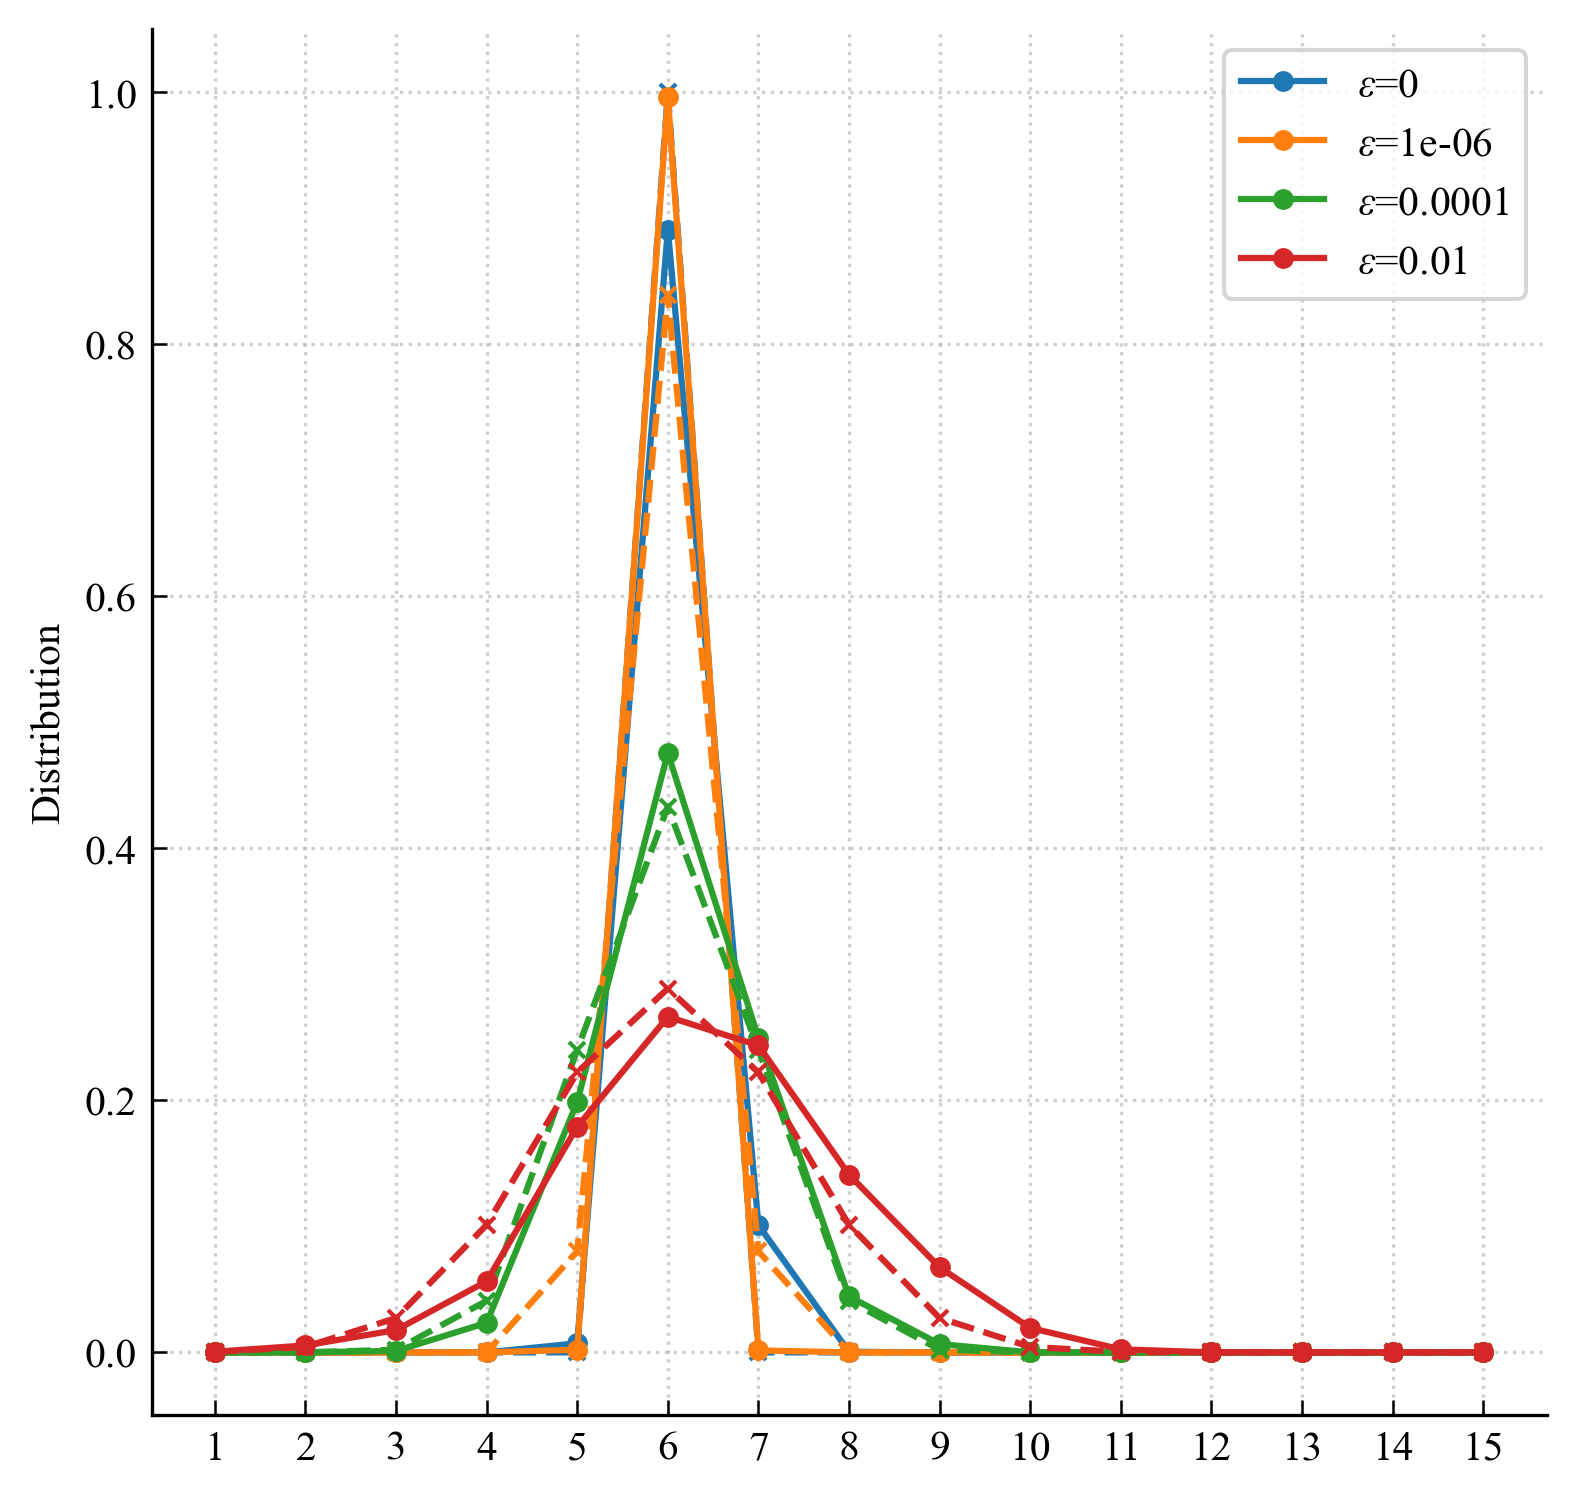

In [22]:
max_block_size = 6
dtype = np.float32
d = 15

model = JordanNet(encode_dim=32).cpu()
pretrained_dimensions = [4, 6, 9, 12, 15, 28] + [35, 33, 25, 23, 19, 13, 7]
for dim in pretrained_dimensions:
    model.add_dimension(dim)

model.load_state_dict(torch.load(f"sandbox/model_jordan8_modified.pth", map_location="cpu"))
model.cpu()
model.eval()

epsilons = [0, 1e-6, 1e-4, 1e-2]

Xs = [generate_matrix(d, max_block_size, mode="random", eps=eps) for eps in epsilons]
X_batch = torch.tensor(Xs, dtype=torch.float32)
features = [per_power_features(X) for X in Xs]
X_features = torch.tensor([f[0] for f in features], dtype=torch.float32)
masks = torch.tensor([f[1] for f in features], dtype=torch.bool)

logits = model(d, X_features, masks=masks)
probs = torch.softmax(logits, dim=-1)
probs = probs.detach().cpu().numpy()

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.figure(figsize=(6,6))

for i, (prob, eps) in enumerate(zip(probs, epsilons)):
    c = colors[i % len(colors)]
    plt.plot(soft_target(torch.tensor([max_block_size]), eps=torch.tensor(eps), d=d).cpu().numpy(), marker='x', linestyle='--', color=c)
    plt.plot(prob, label=f"$\\varepsilon$={eps}", marker='o', linestyle='-', color=c)

plt.legend()
plt.xticks(ticks=range(d), labels=range(1,d+1))
#plt.xlim(6,16)
plt.ylabel("Distribution")
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig("latex/images/j8_target_eample.pdf")
plt.show()
    